# NavigaMer V3.0 Benchmark — 结果复现

本 notebook 仅读取已有的中间结果 JSON，复现全部图表，不运行任何方法。

In [10]:
%matplotlib inline
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

_nb_dir = Path.cwd()
if (_nb_dir / "v3_replot.ipynb").exists():
    METHODS_DIR = _nb_dir
elif (_nb_dir / "methods" / "v3_replot.ipynb").exists():
    METHODS_DIR = _nb_dir / "methods"
else:
    METHODS_DIR = _nb_dir
OUTPUT_DIR = METHODS_DIR / "v3_benchmark_output"

with open(OUTPUT_DIR / "exp1_robustness.json") as f:
    results_exp1 = json.load(f)
with open(OUTPUT_DIR / "exp1_position_recall.json") as f:
    results_exp1_pos = json.load(f)
with open(OUTPUT_DIR / "exp2_search_space.json") as f:
    series_exp2 = json.load(f)
with open(OUTPUT_DIR / "exp4_candidate_quality.json") as f:
    dists_by_method = json.load(f)

exp3_path = OUTPUT_DIR / "exp3_comprehensiveness.json"
if exp3_path.exists():
    with open(exp3_path) as f:
        exp3_data = json.load(f)
    seq_recalls = exp3_data.get("sequence_recall", exp3_data)
    hit_recalls = exp3_data.get("hit_recall", {})
else:
    seq_recalls, hit_recalls = {}, {}

MUTATION_RATES = [r["mutation_rate"] for r in results_exp1["navigamer"]]

COLORS = {"navigamer": "#4C72B0", "strobemer": "#55A868",
          "spaced_seed": "#DD8452", "tensor_sketch": "#C44E52"}
LABELS = {"navigamer": "NavigaMer", "strobemer": "Strobemer",
          "spaced_seed": "Spaced Seed", "tensor_sketch": "Tensor Sketch"}
METHODS = ["navigamer", "strobemer", "spaced_seed", "tensor_sketch"]

print("Loaded from:", OUTPUT_DIR)
print(f"Exp1: {len(MUTATION_RATES)} mutation rates, Exp2: {sum(len(v) for v in series_exp2.values())} configs")
print(f"Exp4: {sum(len(v) for v in dists_by_method.values())} distance samples")

Loaded from: /home/minghao/project/2026/NavigaMer/methods/v3_benchmark_output
Exp1: 8 mutation rates, Exp2: 38 configs
Exp4: 14179 distance samples


## 实验一：鲁棒性边界

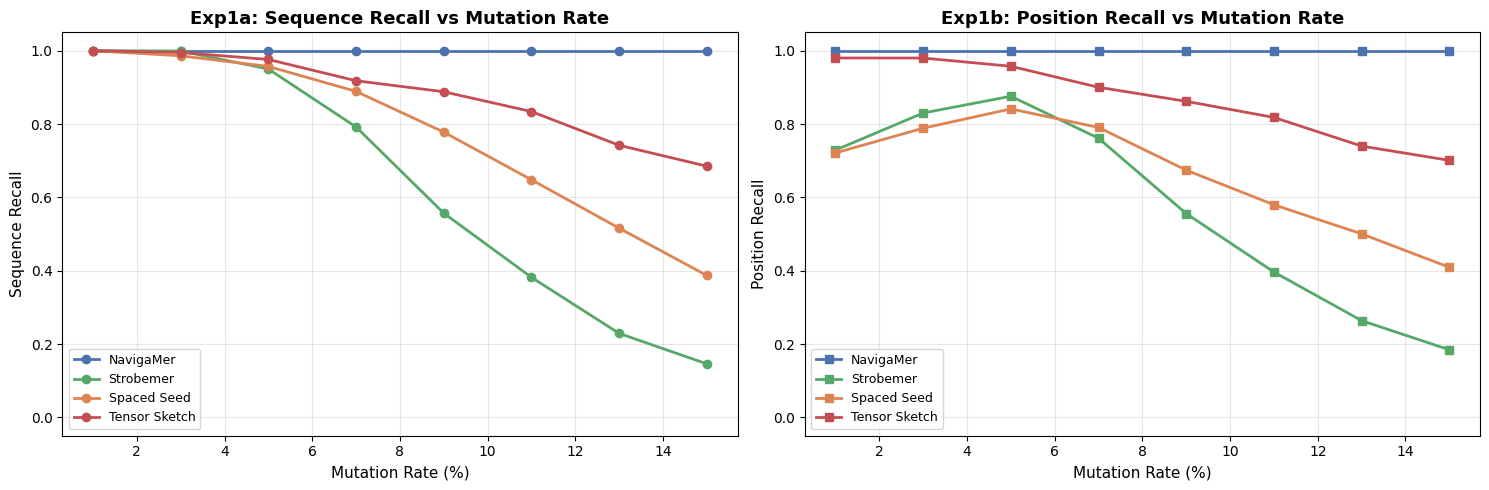

In [11]:
xs = [int(mr * 100) for mr in MUTATION_RATES]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for m in METHODS:
    ys = [r["recall"] for r in results_exp1[m]]
    ax1.plot(xs, ys, marker='o', label=LABELS[m], linewidth=2, color=COLORS[m])
ax1.set_xlabel("Mutation Rate (%)", fontsize=11)
ax1.set_ylabel("Sequence Recall", fontsize=11)
ax1.set_title("Exp1a: Sequence Recall vs Mutation Rate", fontsize=13, fontweight="bold")
ax1.set_ylim(-0.05, 1.05)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

for m in METHODS:
    ys = [r["recall"] for r in results_exp1_pos[m]]
    ax2.plot(xs, ys, marker='s', label=LABELS[m], linewidth=2, color=COLORS[m])
ax2.set_xlabel("Mutation Rate (%)", fontsize=11)
ax2.set_ylabel("Position Recall", fontsize=11)
ax2.set_title("Exp1b: Position Recall vs Mutation Rate", fontsize=13, fontweight="bold")
ax2.set_ylim(-0.05, 1.05)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "exp1_robustness.png", bbox_inches='tight', dpi=150)
plt.show()

## 实验二：搜索空间缩减

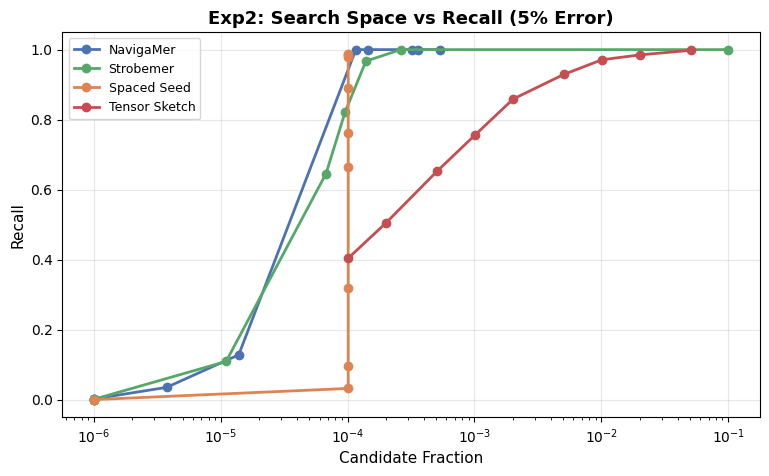

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
for m in METHODS:
    pts = series_exp2[m]
    ax.plot([p["candidate_fraction"] for p in pts],
            [p["recall"] for p in pts],
            marker='o', label=LABELS[m], linewidth=2, color=COLORS[m])
ax.set_xscale("log")
ax.set_xlabel("Candidate Fraction", fontsize=11)
ax.set_ylabel("Recall", fontsize=11)
ax.set_title("Exp2: Search Space vs Recall (5% Error)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.savefig(OUTPUT_DIR / "exp2_search_space_roc.png", bbox_inches='tight', dpi=150)
plt.show()

## 实验四：候选集质量分布

/tmp/ipykernel_44772/361373204.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.5,


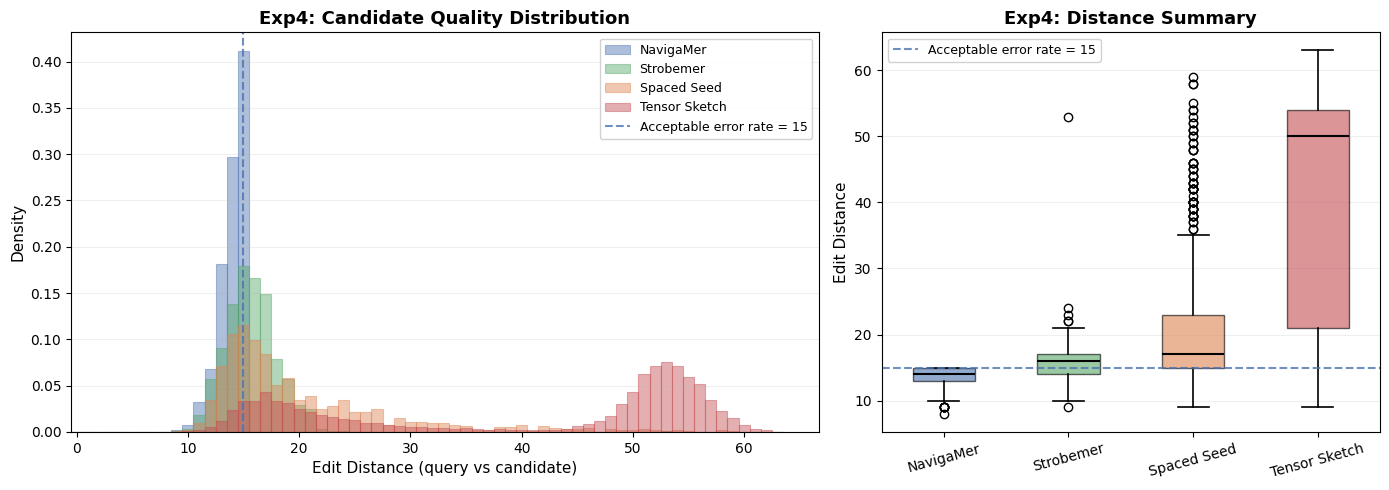

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [3, 2]})

# ── Left: overlaid histogram (density) ──
ax = axes[0]
all_dists = [v for vs in dists_by_method.values() for v in vs if v <= 80]
bins = np.arange(0, max(all_dists) + 2) - 0.5 if all_dists else 20

for m in METHODS:
    d = np.array([x for x in dists_by_method.get(m, []) if x <= 80])
    if len(d) == 0:
        continue
    ax.hist(d, bins=bins, alpha=0.45, density=True, label=LABELS[m],
            color=COLORS[m], edgecolor=COLORS[m], linewidth=0.8)

nav_tol = 15
ax.axvline(nav_tol, color="#4C72B0", linestyle="--", linewidth=1.5, alpha=0.8,
           label=f"Acceptable error rate = {nav_tol}")
ax.set_xlabel("Edit Distance (query vs candidate)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Exp4: Candidate Quality Distribution", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.2, axis="y")
ax.set_xlim(left=-0.5)

# ── Right: box plot ──
ax2 = axes[1]
box_data, box_labels, box_colors = [], [], []
for m in METHODS:
    d = [x for x in dists_by_method.get(m, []) if x <= 80]
    if d:
        box_data.append(d)
        box_labels.append(LABELS[m])
        box_colors.append(COLORS[m])

bp = ax2.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.5,
                 medianprops=dict(color="black", linewidth=1.5),
                 whiskerprops=dict(linewidth=1.2),
                 capprops=dict(linewidth=1.2))
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax2.axhline(nav_tol, color="#4C72B0", linestyle="--", linewidth=1.5, alpha=0.8,
            label=f"Acceptable error rate = {nav_tol}")
ax2.set_ylabel("Edit Distance", fontsize=11)
ax2.set_title("Exp4: Distance Summary", fontsize=13, fontweight="bold")
ax2.legend(fontsize=9, loc="upper left", framealpha=0.9)
ax2.grid(True, alpha=0.2, axis="y")
ax2.tick_params(axis="x", rotation=15)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "exp4_distance_density.png", bbox_inches='tight', dpi=150)
plt.show()

## 汇总图

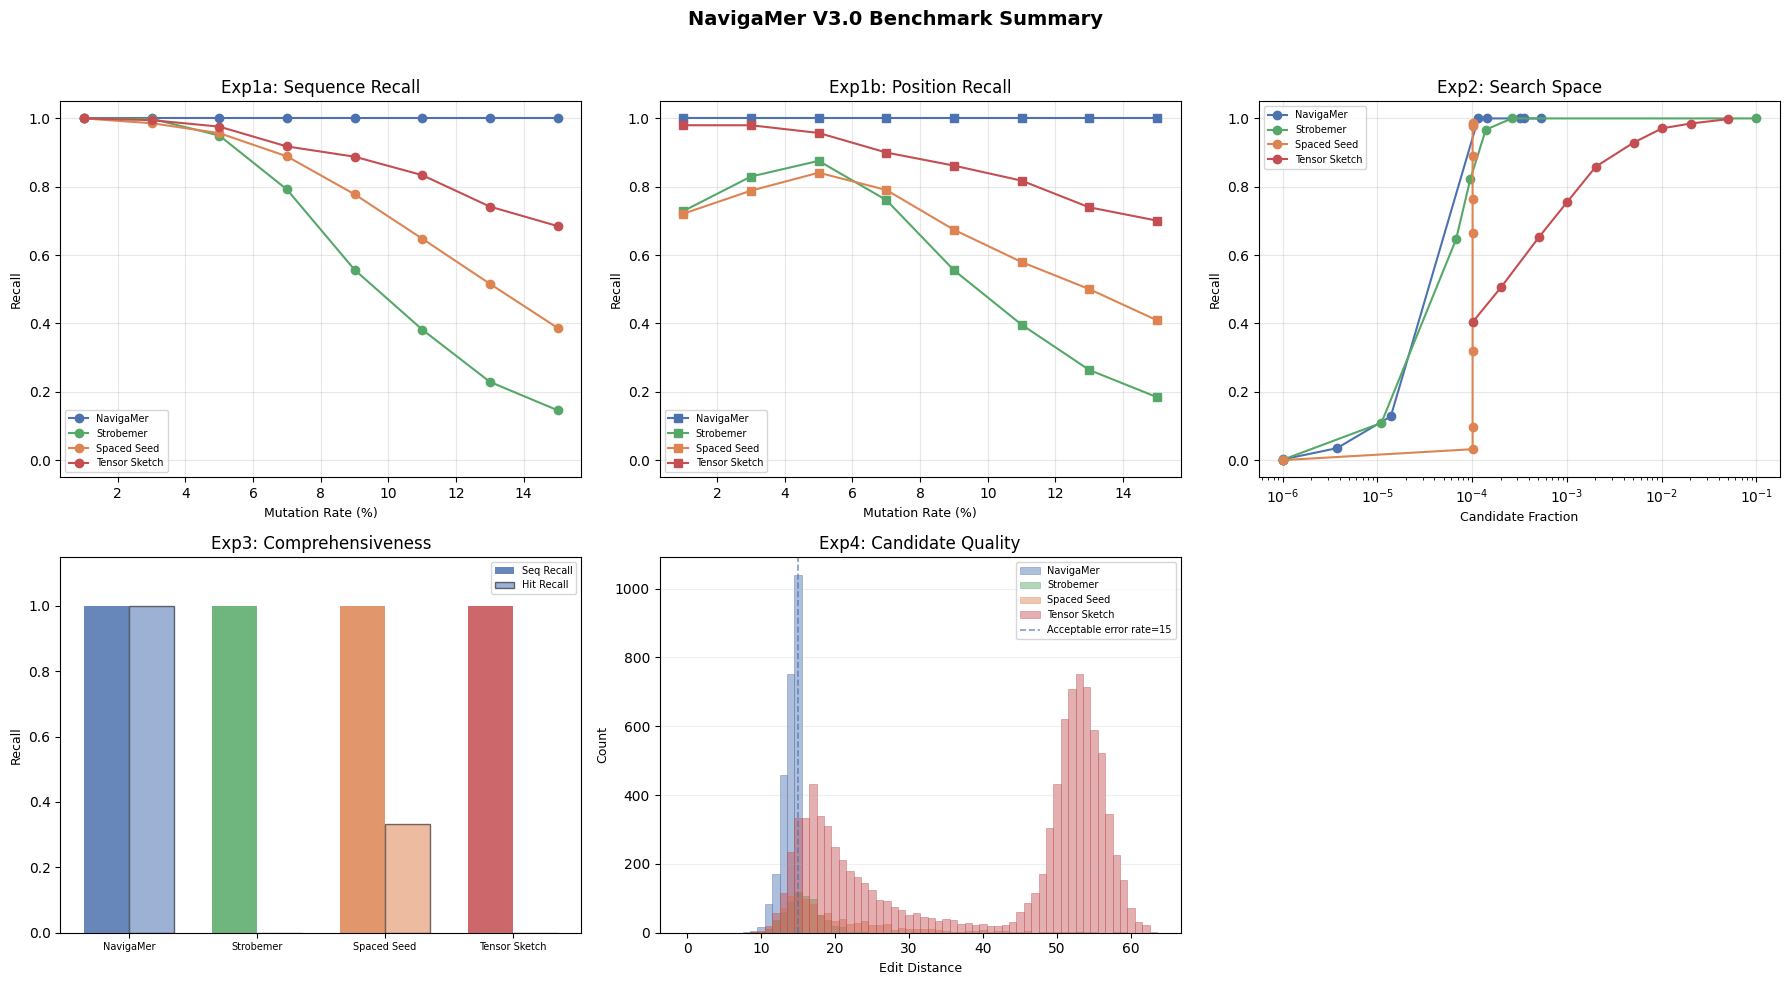

Saved to: /home/minghao/project/2026/NavigaMer/methods/v3_benchmark_output


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
xs = [int(mr * 100) for mr in MUTATION_RATES]

# ── (0,0) Exp1a: Sequence Recall ──
for m in METHODS:
    axes[0, 0].plot(xs, [r["recall"] for r in results_exp1[m]],
                    marker='o', label=LABELS[m], color=COLORS[m])
axes[0, 0].set_xlabel("Mutation Rate (%)", fontsize=9)
axes[0, 0].set_ylabel("Recall", fontsize=9)
axes[0, 0].set_title("Exp1a: Sequence Recall")
axes[0, 0].legend(fontsize=7)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(-0.05, 1.05)

# ── (0,1) Exp1b: Position Recall ──
for m in METHODS:
    axes[0, 1].plot(xs, [r["recall"] for r in results_exp1_pos[m]],
                    marker='s', label=LABELS[m], color=COLORS[m])
axes[0, 1].set_xlabel("Mutation Rate (%)", fontsize=9)
axes[0, 1].set_ylabel("Recall", fontsize=9)
axes[0, 1].set_title("Exp1b: Position Recall")
axes[0, 1].legend(fontsize=7)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(-0.05, 1.05)

# ── (0,2) Exp2: Search Space ──
for m in METHODS:
    pts = series_exp2[m]
    axes[0, 2].plot([p["candidate_fraction"] for p in pts],
                    [p["recall"] for p in pts],
                    marker='o', label=LABELS[m], color=COLORS[m])
axes[0, 2].set_xscale("log")
axes[0, 2].set_xlabel("Candidate Fraction", fontsize=9)
axes[0, 2].set_ylabel("Recall", fontsize=9)
axes[0, 2].set_title("Exp2: Search Space")
axes[0, 2].legend(fontsize=7)
axes[0, 2].grid(True, alpha=0.3)

# ── (1,0) Exp3: Comprehensiveness ──
_keys = METHODS
_lbls = [LABELS[k] for k in _keys]
x3 = np.arange(len(_keys))
w3 = 0.35
axes[1, 0].bar(x3 - w3/2, [seq_recalls.get(k, 0) for k in _keys], w3,
               label="Seq Recall", color=[COLORS[k] for k in _keys], alpha=0.85)
axes[1, 0].bar(x3 + w3/2, [hit_recalls.get(k, 0) for k in _keys], w3,
               label="Hit Recall", color=[COLORS[k] for k in _keys],
               edgecolor='black', linewidth=1.0, alpha=0.55)
axes[1, 0].set_xticks(x3)
axes[1, 0].set_xticklabels(_lbls, fontsize=7)
axes[1, 0].set_ylabel("Recall", fontsize=9)
axes[1, 0].set_title("Exp3: Comprehensiveness" + (" (skipped)" if not seq_recalls else ""))
axes[1, 0].set_ylim(0, 1.15)
axes[1, 0].legend(fontsize=7)

# ── (1,1) Exp4: Candidate Quality ──
_all_d4 = [v for vs in dists_by_method.values() for v in vs if v <= 80]
_bins4 = np.arange(0, max(_all_d4) + 2) - 0.5 if _all_d4 else 20
for m in METHODS:
    d = np.array([x for x in dists_by_method.get(m, []) if x <= 80])
    if len(d) > 0:
        axes[1, 1].hist(d, bins=_bins4, alpha=0.45, color=COLORS[m],
                        edgecolor=COLORS[m], linewidth=0.6, label=LABELS[m])
axes[1, 1].axvline(15, color="#4C72B0", linestyle="--", linewidth=1.2,
                   alpha=0.7, label="Acceptable error rate=15")
axes[1, 1].set_xlabel("Edit Distance", fontsize=9)
axes[1, 1].set_ylabel("Count", fontsize=9)
axes[1, 1].set_title("Exp4: Candidate Quality")
axes[1, 1].legend(fontsize=7)
axes[1, 1].grid(True, alpha=0.2, axis="y")

# ── (1,2) unused ──
axes[1, 2].set_visible(False)

plt.suptitle("NavigaMer V3.0 Benchmark Summary", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(OUTPUT_DIR / "summary.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved to:", OUTPUT_DIR)

---

## 无文字版（仅保留 legend，字体 Arial）

以下为去掉所有 title / xlabel / ylabel / tick labels 的版本，仅保留 legend（使用 Arial 字体）。

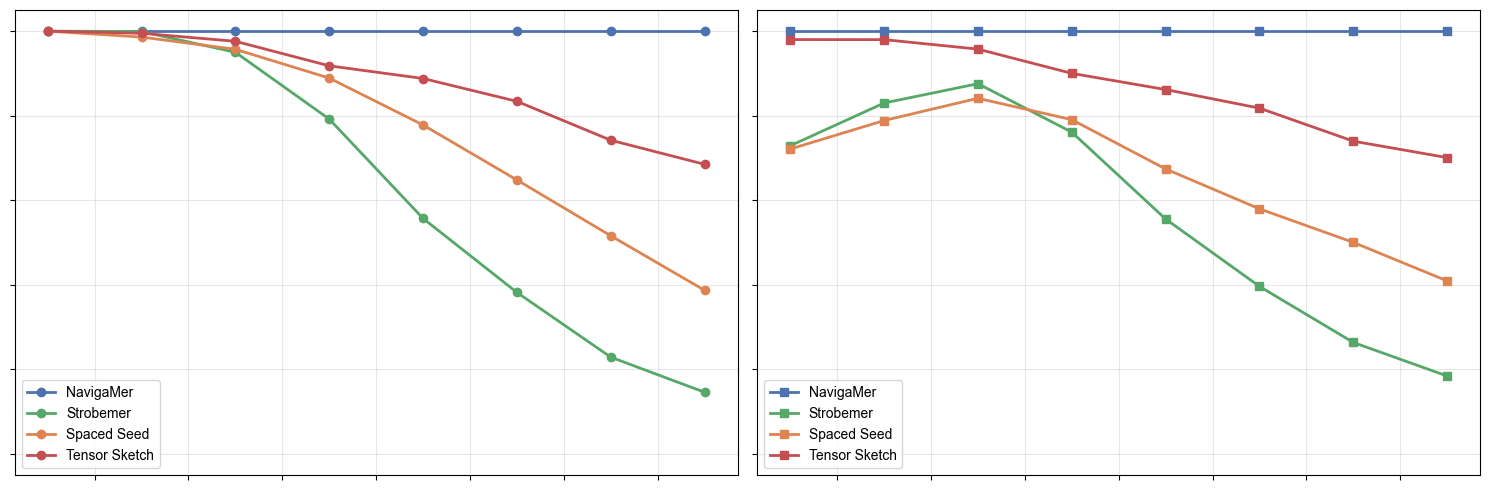

In [15]:
import matplotlib.font_manager as fm

fm.fontManager.__init__()
_arial_prop = fm.FontProperties(family='Arial')

xs = [int(mr * 100) for mr in MUTATION_RATES]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for m in METHODS:
    ys = [r["recall"] for r in results_exp1[m]]
    ax1.plot(xs, ys, marker='o', label=LABELS[m], linewidth=2, color=COLORS[m])
ax1.set_ylim(-0.05, 1.05)
ax1.legend(fontsize=9, prop=_arial_prop)
ax1.grid(True, alpha=0.3)
ax1.set_title("")
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.set_xticklabels([])
ax1.set_yticklabels([])

for m in METHODS:
    ys = [r["recall"] for r in results_exp1_pos[m]]
    ax2.plot(xs, ys, marker='s', label=LABELS[m], linewidth=2, color=COLORS[m])
ax2.set_ylim(-0.05, 1.05)
ax2.legend(fontsize=9, prop=_arial_prop)
ax2.grid(True, alpha=0.3)
ax2.set_title("")
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_xticklabels([])
ax2.set_yticklabels([])

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "exp1_robustness_notext.png", bbox_inches='tight', dpi=150)
plt.show()

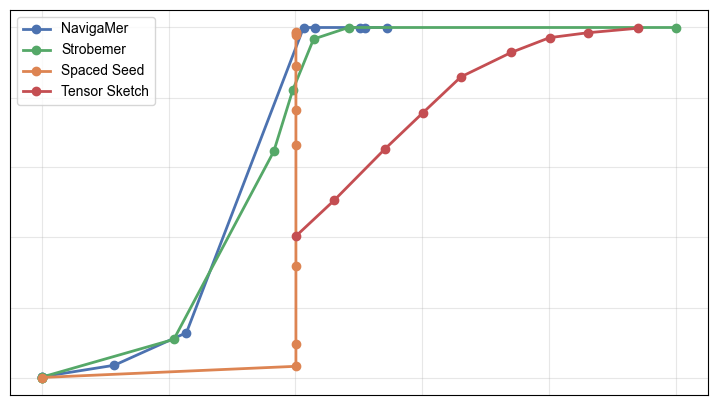

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
for m in METHODS:
    pts = series_exp2[m]
    ax.plot([p["candidate_fraction"] for p in pts],
            [p["recall"] for p in pts],
            marker='o', label=LABELS[m], linewidth=2, color=COLORS[m])
ax.set_xscale("log")
ax.legend(fontsize=9, prop=_arial_prop)
ax.grid(True, alpha=0.3)
ax.set_title("")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.tick_params(axis='both', which='both', length=0)
fig.savefig(OUTPUT_DIR / "exp2_search_space_roc_notext.png", bbox_inches='tight', dpi=150)
plt.show()

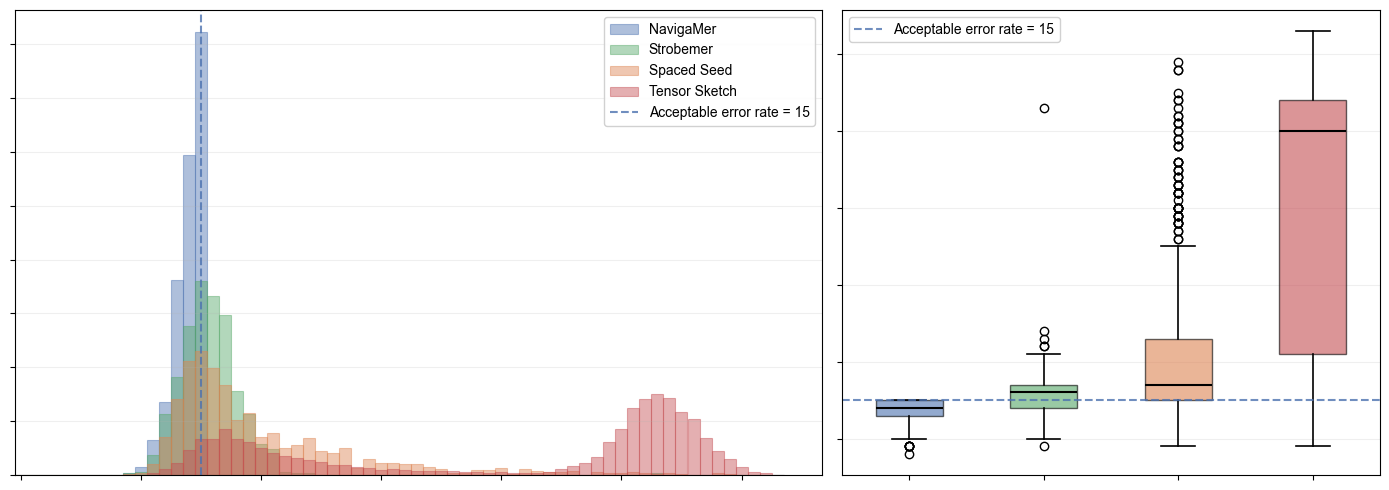

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [3, 2]})

# ── Left: overlaid histogram (density) ──
ax = axes[0]
all_dists = [v for vs in dists_by_method.values() for v in vs if v <= 80]
bins = np.arange(0, max(all_dists) + 2) - 0.5 if all_dists else 20

for m in METHODS:
    d = np.array([x for x in dists_by_method.get(m, []) if x <= 80])
    if len(d) == 0:
        continue
    ax.hist(d, bins=bins, alpha=0.45, density=True, label=LABELS[m],
            color=COLORS[m], edgecolor=COLORS[m], linewidth=0.8)

nav_tol = 15
ax.axvline(nav_tol, color="#4C72B0", linestyle="--", linewidth=1.5, alpha=0.8,
           label=f"Acceptable error rate = {nav_tol}")
ax.legend(fontsize=9, framealpha=0.9, prop=_arial_prop)
ax.grid(True, alpha=0.2, axis="y")
ax.set_xlim(left=-0.5)
ax.set_title("")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels([])
ax.set_yticklabels([])

# ── Right: box plot ──
ax2 = axes[1]
box_data, box_labels, box_colors = [], [], []
for m in METHODS:
    d = [x for x in dists_by_method.get(m, []) if x <= 80]
    if d:
        box_data.append(d)
        box_labels.append("")
        box_colors.append(COLORS[m])

bp = ax2.boxplot(box_data, tick_labels=[""] * len(box_data), patch_artist=True, widths=0.5,
                 medianprops=dict(color="black", linewidth=1.5),
                 whiskerprops=dict(linewidth=1.2),
                 capprops=dict(linewidth=1.2))
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax2.axhline(nav_tol, color="#4C72B0", linestyle="--", linewidth=1.5, alpha=0.8,
            label=f"Acceptable error rate = {nav_tol}")
ax2.legend(fontsize=9, loc="upper left", framealpha=0.9, prop=_arial_prop)
ax2.grid(True, alpha=0.2, axis="y")
ax2.set_title("")
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_xticklabels([])
ax2.set_yticklabels([])

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "exp4_distance_density_notext.png", bbox_inches='tight', dpi=150)
plt.show()

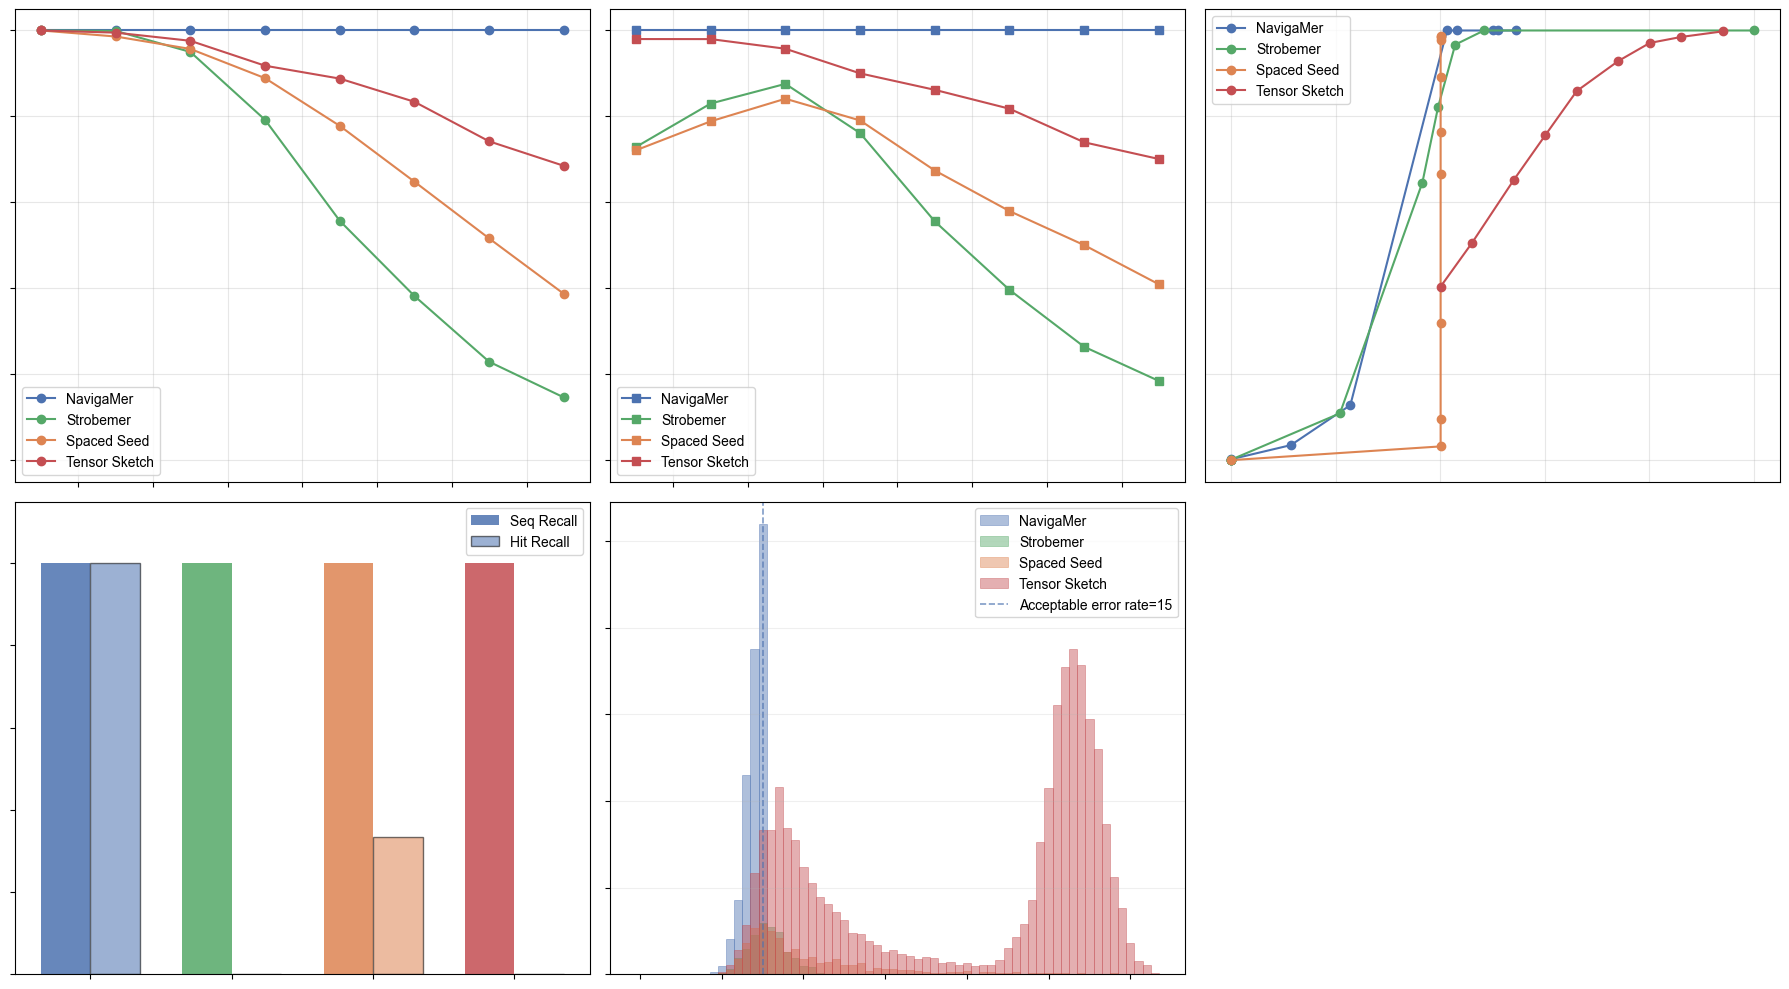

Saved to: /home/minghao/project/2026/NavigaMer/methods/v3_benchmark_output


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
xs = [int(mr * 100) for mr in MUTATION_RATES]

# ── (0,0) Exp1a: Sequence Recall ──
for m in METHODS:
    axes[0, 0].plot(xs, [r["recall"] for r in results_exp1[m]],
                    marker='o', label=LABELS[m], color=COLORS[m])
axes[0, 0].legend(fontsize=7, prop=_arial_prop)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(-0.05, 1.05)
axes[0, 0].set_title("")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("")
axes[0, 0].set_xticklabels([])
axes[0, 0].set_yticklabels([])

# ── (0,1) Exp1b: Position Recall ──
for m in METHODS:
    axes[0, 1].plot(xs, [r["recall"] for r in results_exp1_pos[m]],
                    marker='s', label=LABELS[m], color=COLORS[m])
axes[0, 1].legend(fontsize=7, prop=_arial_prop)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(-0.05, 1.05)
axes[0, 1].set_title("")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("")
axes[0, 1].set_xticklabels([])
axes[0, 1].set_yticklabels([])

# ── (0,2) Exp2: Search Space ──
for m in METHODS:
    pts = series_exp2[m]
    axes[0, 2].plot([p["candidate_fraction"] for p in pts],
                    [p["recall"] for p in pts],
                    marker='o', label=LABELS[m], color=COLORS[m])
axes[0, 2].set_xscale("log")
axes[0, 2].legend(fontsize=7, prop=_arial_prop)
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].set_title("")
axes[0, 2].set_xlabel("")
axes[0, 2].set_ylabel("")
axes[0, 2].set_xticklabels([])
axes[0, 2].set_yticklabels([])
axes[0, 2].tick_params(axis='both', which='both', length=0)

# ── (1,0) Exp3: Comprehensiveness ──
_keys = METHODS
x3 = np.arange(len(_keys))
w3 = 0.35
axes[1, 0].bar(x3 - w3/2, [seq_recalls.get(k, 0) for k in _keys], w3,
               label="Seq Recall", color=[COLORS[k] for k in _keys], alpha=0.85)
axes[1, 0].bar(x3 + w3/2, [hit_recalls.get(k, 0) for k in _keys], w3,
               label="Hit Recall", color=[COLORS[k] for k in _keys],
               edgecolor='black', linewidth=1.0, alpha=0.55)
axes[1, 0].set_xticks(x3)
axes[1, 0].set_xticklabels([])
axes[1, 0].set_yticklabels([])
axes[1, 0].set_ylim(0, 1.15)
axes[1, 0].legend(fontsize=7, prop=_arial_prop)
axes[1, 0].set_title("")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("")

# ── (1,1) Exp4: Candidate Quality ──
_all_d4 = [v for vs in dists_by_method.values() for v in vs if v <= 80]
_bins4 = np.arange(0, max(_all_d4) + 2) - 0.5 if _all_d4 else 20
for m in METHODS:
    d = np.array([x for x in dists_by_method.get(m, []) if x <= 80])
    if len(d) > 0:
        axes[1, 1].hist(d, bins=_bins4, alpha=0.45, color=COLORS[m],
                        edgecolor=COLORS[m], linewidth=0.6, label=LABELS[m])
axes[1, 1].axvline(15, color="#4C72B0", linestyle="--", linewidth=1.2,
                   alpha=0.7, label="Acceptable error rate=15")
axes[1, 1].legend(fontsize=7, prop=_arial_prop)
axes[1, 1].grid(True, alpha=0.2, axis="y")
axes[1, 1].set_title("")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("")
axes[1, 1].set_xticklabels([])
axes[1, 1].set_yticklabels([])

# ── (1,2) unused ──
axes[1, 2].set_visible(False)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "summary_notext.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved to:", OUTPUT_DIR)